In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
# Load dataset
df = pd.read_csv(
    "preprocessed_dataset.csv",
    engine='python',
    on_bad_lines='skip'
)

print("Preprocessed dataset loaded successfully!\n")


Preprocessed dataset loaded successfully!



In [ ]:
# Filter small categories, split the dataset, and create TF-IDF

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import save_npz
import pickle

# Keep only valid rows
classification_df = df[
    ["cleaned_text", "category"]
].dropna().copy()

classification_df["cleaned_text"] = (
    classification_df["cleaned_text"]
    .astype(str)
    .str.strip()
)

classification_df = classification_df[
    classification_df["cleaned_text"] != ""
].copy()

# Count papers in every category
category_counts = classification_df["category"].value_counts()

# Keep categories containing at least 150 papers
minimum_papers = 150

selected_categories = category_counts[
    category_counts >= minimum_papers
].index

classification_df = classification_df[
    classification_df["category"].isin(selected_categories)
].reset_index(drop=True)

print("Minimum papers per category:", minimum_papers)
print("Papers before category filtering:", len(df))
print("Papers after category filtering:", len(classification_df))
print("Categories after filtering:", classification_df["category"].nunique())
print(
    "Smallest selected category:",
    classification_df["category"].value_counts().min()
)

# Define input and target
X = classification_df["cleaned_text"]
y = classification_df["category"]

# Split before creating TF-IDF
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nDataset split successfully!")
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

# Create TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\nTF-IDF features created successfully!")
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

# Save matrices and vectorizer
save_npz("tfidf_train_matrix.npz", X_train_tfidf)
save_npz("tfidf_test_matrix.npz", X_test_tfidf)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf_vectorizer, file)

print("\nTF-IDF matrices and vectorizer saved successfully!")

Minimum papers per category: 150
Papers before category filtering: 287421
Papers after category filtering: 284130
Categories after filtering: 55
Smallest selected category: 151

Dataset split successfully!
Training records: 227304
Testing records: 56826

TF-IDF features created successfully!
Training TF-IDF shape: (227304, 5000)
Testing TF-IDF shape: (56826, 5000)

TF-IDF matrices and vectorizer saved successfully!


In [ ]:
# Check main columns

print("Category column exists:", "category" in df.columns)
print("cleaned_text column exists:", "cleaned_text" in df.columns)

print("\nNumber of unique categories:")
print(df["category"].nunique())

print("\nTop 10 categories:")
display(df["category"].value_counts().head(10))

print("\nMissing values:")
print("cleaned_text missing:", df["cleaned_text"].isnull().sum())
print("category missing:", df["category"].isnull().sum())

Category column exists: True
cleaned_text column exists: True

Number of unique categories:
146

Top 10 categories:


,count
category,
Machine Learning,80452
Computer Vision and Pattern Recognition,71106
Computation and Language (Natural Language Processing),37251
Artificial Intelligence,28726
Machine Learning (Statistics),13892
Neural and Evolutionary Computing,6715
Robotics,5254
Cryptography and Security,4376
Image and Video Processing,2771



Missing values:
cleaned_text missing: 0
category missing: 0


In [ ]:
# Train Logistic Regression

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Fix label problem if category has only one class
if y.nunique() < 2:
    print("Only one class found in category column.")
    print("Trying to use category_code instead...")

    df = df.dropna(subset=["cleaned_text", "category_code"]).copy()

    category_counts = df["category_code"].value_counts()
    selected_categories = category_counts[category_counts >= 20].index

    if len(selected_categories) < 2:
        selected_categories = category_counts.head(5).index

    df_filtered = df[df["category_code"].isin(selected_categories)].copy()

    X = df_filtered["cleaned_text"].astype(str)
    y = df_filtered["category_code"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    tfidf_vectorizer = TfidfVectorizer(max_features=20000)

    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    X_test_tfidf = tfidf_vectorizer.transform(X_test)

    print("Fixed using category_code.")
    print("Number of classes:", y.nunique())

log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

log_reg_model.fit(X_train_tfidf, y_train)

y_pred_log_reg = log_reg_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully!")
print("Number of classes used:", y.nunique())

Logistic Regression model trained successfully!
Number of classes used: 55


In [ ]:

# Evaluate Logistic Regression Model


log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)

print("Logistic Regression Accuracy:")
print(log_reg_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg, zero_division=0))

Logistic Regression Accuracy:
0.5214514482807165

Classification Report:
                                                                  precision    recall  f1-score   support

                                       Applications (Statistics)       0.07      0.47      0.13       101
                                         Artificial Intelligence       0.59      0.32      0.42      5745
                                 Atmospheric and Oceanic Physics       0.16      0.72      0.27        43
                                     Audio and Speech Processing       0.19      0.49      0.27       140
                                                    Biomolecules       0.16      0.65      0.26        48
                                                Chemical Physics       0.18      0.62      0.27        47
                                        Computation (Statistics)       0.13      0.60      0.21        72
                      Computation and Language (Legacy category)       0.30   

In [ ]:
# Train Naive Bayes

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [ ]:
# Evaluate Naive Bayes

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:")
print(nb_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

Naive Bayes Accuracy:
0.6598915989159891

Classification Report:
                                                                  precision    recall  f1-score   support

                                       Applications (Statistics)       0.00      0.00      0.00       101
                                         Artificial Intelligence       0.51      0.53      0.52      5745
                                 Atmospheric and Oceanic Physics       0.00      0.00      0.00        43
                                     Audio and Speech Processing       0.00      0.00      0.00       140
                                                    Biomolecules       0.00      0.00      0.00        48
                                                Chemical Physics       0.00      0.00      0.00        47
                                        Computation (Statistics)       0.00      0.00      0.00        72
                      Computation and Language (Legacy category)       1.00      0.03 

In [ ]:
# Train LinearSVC

svc_model = LinearSVC(
    random_state=42,
    class_weight="balanced"
)


svc_model.fit(X_train_tfidf, y_train)

y_pred_svc = svc_model.predict(X_test_tfidf)

print("LinearSVC model trained successfully!")

LinearSVC model trained successfully!


In [ ]:
# Evaluate LinearSVC

svc_accuracy = accuracy_score(y_test, y_pred_svc)

print("LinearSVC Accuracy:")
print(svc_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc, zero_division=0))

LinearSVC Accuracy:
0.6019603702530532

Classification Report:
                                                                  precision    recall  f1-score   support

                                       Applications (Statistics)       0.08      0.31      0.13       101
                                         Artificial Intelligence       0.61      0.37      0.46      5745
                                 Atmospheric and Oceanic Physics       0.23      0.56      0.32        43
                                     Audio and Speech Processing       0.15      0.33      0.21       140
                                                    Biomolecules       0.15      0.40      0.22        48
                                                Chemical Physics       0.21      0.43      0.28        47
                                        Computation (Statistics)       0.12      0.39      0.19        72
                      Computation and Language (Legacy category)       0.44      0.74   

In [ ]:
# Compare classification model performance

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "LinearSVC"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svc)
    ],
    "Macro F1-Score": [
        f1_score(
            y_test,
            y_pred_log_reg,
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_nb,
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_svc,
            average="macro",
            zero_division=0
        )
    ],
    "Weighted F1-Score": [
        f1_score(
            y_test,
            y_pred_log_reg,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_nb,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_svc,
            average="weighted",
            zero_division=0
        )
    ]
})

# Macro F1 is important because the categories are imbalanced
model_comparison = model_comparison.sort_values(
    by=["Macro F1-Score", "Weighted F1-Score"],
    ascending=False
).reset_index(drop=True)

print("Classification Model Comparison:")
display(model_comparison.round(4))

Classification Model Comparison:


,Model,Accuracy,Macro F1-Score,Weighted F1-Score
0,LinearSVC,0.6020,0.3432,0.6246
1,Logistic Regression,0.5215,0.3400,0.5590
2,Naive Bayes,0.6599,0.1418,0.6262


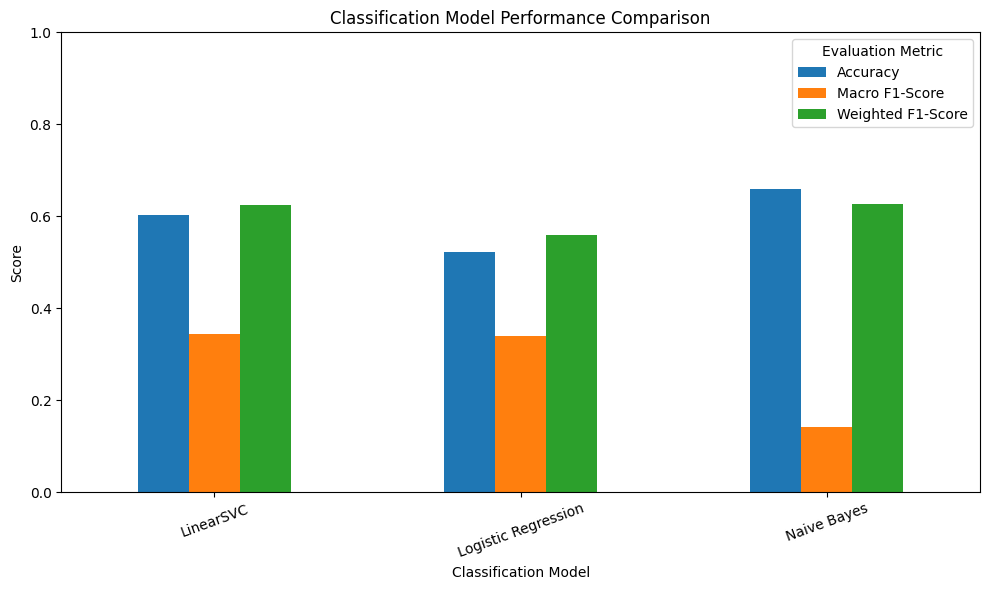

In [ ]:
# Plot classification model performance

comparison_plot = model_comparison.set_index("Model")[
    [
        "Accuracy",
        "Macro F1-Score",
        "Weighted F1-Score"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Classification Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Evaluation Metric")
plt.tight_layout()
plt.show()

In [ ]:
# Select and summarize the best model

model_objects = {
    "Logistic Regression": log_reg_model,
    "Naive Bayes": nb_model,
    "LinearSVC": svc_model
}

prediction_objects = {
    "Logistic Regression": y_pred_log_reg,
    "Naive Bayes": y_pred_nb,
    "LinearSVC": y_pred_svc
}

best_model_name = model_comparison.iloc[0]["Model"]
best_model = model_objects[best_model_name]
best_predictions = prediction_objects[best_model_name]

print("Selected Best Model:", best_model_name)

print("\nBest Model Results:")
display(model_comparison.iloc[[0]].round(4))

print("\nDetailed Classification Report:")
print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

Selected Best Model: LinearSVC

Best Model Results:


,Model,Accuracy,Macro F1-Score,Weighted F1-Score
0,LinearSVC,0.602,0.3432,0.6246



Detailed Classification Report:
                                                                  precision    recall  f1-score   support

                                       Applications (Statistics)       0.08      0.31      0.13       101
                                         Artificial Intelligence       0.61      0.37      0.46      5745
                                 Atmospheric and Oceanic Physics       0.23      0.56      0.32        43
                                     Audio and Speech Processing       0.15      0.33      0.21       140
                                                    Biomolecules       0.15      0.40      0.22        48
                                                Chemical Physics       0.21      0.43      0.28        47
                                        Computation (Statistics)       0.12      0.39      0.19        72
                      Computation and Language (Legacy category)       0.44      0.74      0.55       150
          Co

In [ ]:
# Normalized confusion matrix for the 10 largest categories

prediction_series = pd.Series(
    best_predictions,
    index=y_test.index
)

top_categories = (
    y_test.value_counts()
    .head(10)
    .index
    .tolist()
)

top_mask = y_test.isin(top_categories)

actual_top = y_test[top_mask]

predicted_top = prediction_series[top_mask].where(
    prediction_series[top_mask].isin(top_categories),
    "Other"
)

cm_df = pd.crosstab(
    actual_top,
    predicted_top,
    normalize="index"
)

ordered_columns = [
    category
    for category in top_categories
    if category in cm_df.columns
]

if "Other" in cm_df.columns:
    ordered_columns.append("Other")

cm_df = cm_df[ordered_columns]

print("Normalized Confusion Matrix — 10 Largest Categories:")
display((cm_df * 100).round(2))

Normalized Confusion Matrix — 10 Largest Categories:


col_0,Machine Learning,Computer Vision and Pattern Recognition,Computation and Language (Natural Language Processing),Artificial Intelligence,Machine Learning (Statistics),Neural and Evolutionary Computing,Robotics,Cryptography and Security,Image and Video Processing,Information Retrieval,Other
category,,,,,,,,,,,
Artificial Intelligence,7.00,3.71,8.13,37.35,0.78,2.99,2.21,2.07,0.26,2.23,33.26
Computation and Language (Natural Language Processing),2.26,1.97,77.81,4.07,0.21,0.16,0.05,1.19,0.07,2.24,9.96
Computer Vision and Pattern Recognition,2.50,79.80,0.84,0.84,0.44,0.70,1.67,0.66,4.81,0.29,7.45
Cryptography and Security,4.34,2.74,1.60,1.49,0.11,0.80,0.57,77.49,0.00,0.46,10.40
Image and Video Processing,1.81,31.41,0.36,0.54,0.36,0.36,0.54,0.00,52.35,0.00,12.27
Information Retrieval,2.03,1.66,9.59,3.14,1.48,0.55,0.00,0.18,0.18,69.74,11.44
Machine Learning,45.99,3.81,3.46,3.92,7.53,2.86,1.12,2.27,0.84,1.22,27.00
Machine Learning (Statistics),20.30,2.30,0.90,1.48,32.58,1.94,0.36,0.32,0.65,0.58,38.59
Neural and Evolutionary Computing,4.84,2.38,0.67,1.41,0.67,72.38,1.12,0.37,0.07,0.22,15.86


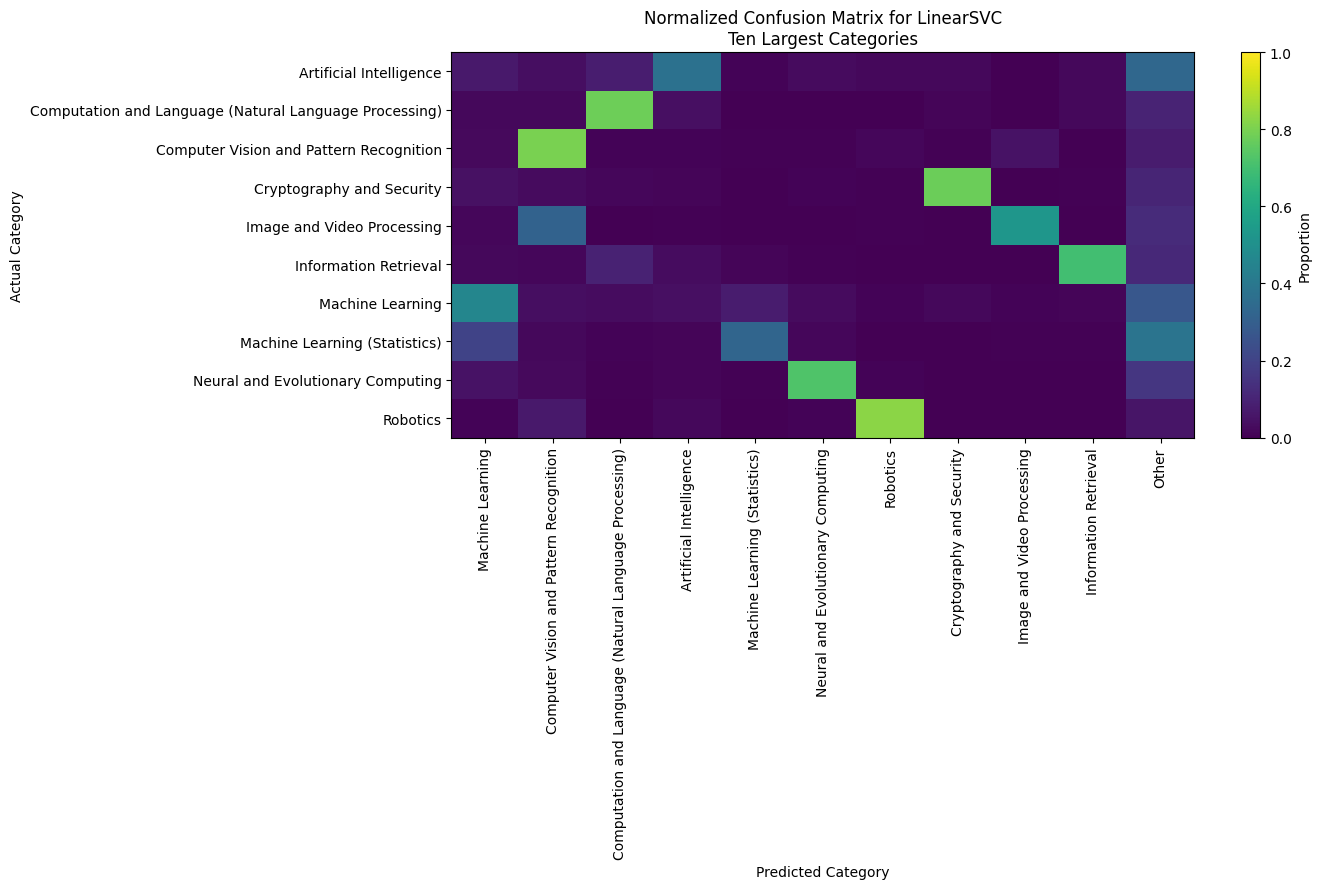

In [ ]:
# Plot the normalized confusion matrix

plt.figure(figsize=(14, 9))

plt.imshow(
    cm_df,
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.title(
    f"Normalized Confusion Matrix for {best_model_name}\n"
    "Ten Largest Categories"
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(
    range(len(cm_df.columns)),
    cm_df.columns,
    rotation=90
)

plt.yticks(
    range(len(cm_df.index)),
    cm_df.index
)

plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()

In [ ]:
# Save model and vectorizer

import pickle

# Save the best classification model
with open("best_classification_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save the TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf_vectorizer, file)

print("Files saved successfully:")
print("- best_classification_model.pkl")
print("- tfidf_vectorizer.pkl")

Files saved successfully:
- best_classification_model.pkl
- tfidf_vectorizer.pkl


In [ ]:
# Check saved files

import os

print("best_classification_model.pkl exists:", os.path.exists("best_classification_model.pkl"))
print("tfidf_vectorizer.pkl exists:", os.path.exists("tfidf_vectorizer.pkl"))

best_classification_model.pkl exists: True
tfidf_vectorizer.pkl exists: True
